In [35]:
import numpy as np
import pandas as pd
import os
import sys
import glob
import torch.nn as nn
from transformers import AutoConfig
from safetensors.torch import load_file  # comes with HF if safetensors installed
from sklearn.metrics import classification_report, recall_score
import tqdm
import re
import ast
from typing import List
import torch
import matplotlib.pyplot as plt
os.chdir("/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis")
sys.path.append("../../benchmark")
import test_base
from sentence_splitter import split_text_into_sentences
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from BERT_classifier.Classify_report_with_BERT import tf_idf

# Test using a BERT-Classification Model trained on paragraphs to classify an entire report.

**Function:** pdf -> NACE Class

## Load Data

In [36]:
dataset_path = "data/datasets/german_annual_reports"
dataset_path = "data/datasets/stoxx_600_extended"
dataset_path = "data/datasets/reports_subset_from_full_data_1"
dataset_path = "data/datasets/reports_subset_from_full_data_3"
dataset_path = "data/datasets/stoxx_600"

In [37]:
over_view_df_path = os.path.join(dataset_path, os.path.basename(dataset_path) + "_overview.csv")

dataset_path_texts = os.path.join(dataset_path, "TXTs")

dataset_name = os.path.basename(dataset_path)

In [38]:
cos_sim_path = "results/dataset__reports_subset_from_full_data_3_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1"
cos_sim_report_paths = glob.glob(cos_sim_path + "/*/*.csv")
len(cos_sim_report_paths)

813

In [39]:
results_path = "results/BERT_classification/dataset__stoxx_600_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/2_dataset__reports_subset_from_full_data_1_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/model_0_1__dataset__stoxx_600_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/model_2_1__with_relevancy__dataset__reports_subset_from_full_data_3_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/model_1_0__with_relevancy__dataset__reports_subset_from_full_data_3_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/model_2_2__BERT_preprocessing__desc_pages__with_relevancy__dataset__stoxx_600_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/model_2_2__desc_pages__with_relevancy__dataset__stoxx_600_sentence_len_6__nace_level_1"
reports_results = glob.glob(results_path+ "/*/*.csv")
len(reports_results)

61

In [40]:
a = [os.path.basename(b).replace("_long.csv", "") for b in cos_sim_report_paths]

In [41]:
b = [os.path.basename(b).replace("_classifications.csv", "") for b in reports_results]

In [42]:
# for cos in cos_sim_report_paths: 
#     print(os.path.basename(cos).replace("_long.csv", "") in b)
#     print(os.path.exists(cos))

In [43]:
nace_classes = pd.read_csv(over_view_df_path, index_col=0, sep=";")
nace_classes.head()

,Name,Symbol,FactSet ID,Revenue - 2022 (in EUR),Revenue - 2023 (in EUR),Revenue - 2024 (in EUR),NACE,NACE_letter,Report,description_page
483,3i Group plc,III-GB,III-GB,701.210162,1276.962137,NaN,66.30,K,NaN,NaN
354,A.P. Moller - Maersk A/S Class B,MAERSK.B-DK,MAERSK.B-DK,77568.022858,47226.219381,51288.2262335699,50.20,H,NaN,NaN
275,A2A S.p.A.,A2A-IT,A2A-IT,22938.000000,14492.000000,NaN,35.11,D,NaN,NaN
107,AAK AB,AAK-SE,AAK-SE,4741.086317,4010.433824,3939.34280627966,10.89,C,AAK AB1.pdf,3
122,Aalberts N.V.,AALB-NL,AALB-NL,3230.000000,3324.000000,3148.6,25.93,C,Aalberts N.V.1.pdf,NaN


In [44]:
report_to_nace_class = nace_classes.dropna(subset=["Report"]).set_index('Report').to_dict()["NACE"]
report_to_nace_class = {report[0][:-4] + ".txt": report[1] for report in report_to_nace_class.items()}
len(report_to_nace_class)

291

In [45]:
reports_path = glob.glob(os.path.join(dataset_path_texts, "*.txt"))
len(reports_path)

263

## Define Aggregation methods

In [46]:
def softmax(x):
    e = np.exp(x - np.max(x))   # subtract max for numerical stability
    return e / e.sum()

In [47]:
def majority_vote(df: pd.DataFrame, scores: list, threshold: float = 0, **kwargs) -> dict:
    
    df.loc[:,"max_class_sim"] = [scores[i] for i in np.argmax(df[scores], 1)]
    df.loc[:,"max_sim"] = df[scores].max(1)
    df = df[df["max_sim"] > threshold]
    evaluation = (df["max_class_sim"].value_counts() / len(df)).sort_values(ascending=False).to_dict()

    return evaluation

In [48]:
def confidence_weighted_voting(df: pd.DataFrame, scores: list, threshold: float = 0, **kwargs) -> dict:

    df.loc[:,"max_class_sim"] = [scores[i] for i in np.argmax(df[scores], 1)]
    df.loc[:,"max_sim"] = df[scores].max(1)
    df = df[df["max_sim"] > threshold]
    evaluation = (df.groupby("max_class_sim")["max_sim"].sum().sort_values(ascending=False)/len(df)).to_dict()

    return evaluation

In [49]:
def logit_stacking(df: pd.DataFrame, scores: list, threshold: float = 0, **kwargs) -> dict:

    df.loc[:,"max_sim"] = df[scores].max(1)
    df = df[df["max_sim"] > threshold]

    stacked = df[scores].sum(0)
    
    evaluation = stacked.to_dict()

    return evaluation

In [50]:
def max_class_voting(df: pd.DataFrame, scores: list, threshold: float = 0, **kwargs) -> dict:

    df.loc[:,"max_class_sim"] = [scores[i] for i in np.argmax(df[scores], 1)]
    df.loc[:,"max_sim"] = df[scores].max(1)
    
    max_sim = df["max_sim"].max()
    res_class = df[df["max_sim"] == max_sim].sum(0)[scores]

    return res_class.to_dict()

In [51]:
# train_df = pd.read_csv("data/training_data/dataset_reports_subset_from_full_data_1__sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__2nd_approach__nace_level_1__cos_thres_0.4/full_data.csv")

# training_reports = train_df["text"].to_list()

# #Build TF-IDF model on all sentences from the training corpus
# tfidf_vectorizer = tf_idf.build_tfidf_model(training_reports)

In [52]:
def logit_stacking_conformal_prediction(df: pd.DataFrame, scores: list, threshold: float = 0, **kwargs) -> set:

    df.loc[:,"max_sim"] = df[scores].max(1)
    df = df[df["max_sim"] > threshold]

    stacked = df[scores].sum(0)

    evaluation = stacked.to_dict()
    
    return evaluation

In [53]:
def tf_idf_weighted(df: pd.DataFrame, scores: list, threshold: float = 0, df_full: pd.DataFrame = None, k = 10) -> dict:
    shortened, ranked = tf_idf.select_top_sentences(
        report_paragraphs=df_full["Sentences"].to_list(),
        vectorizer=tfidf_vectorizer,
        max_words=2000
    )
    df_full = df_full.iloc[np.array(ranked)[:,2][:k]]
    
    #print(len(df_full))

    evaluation = logit_stacking(df_full.copy(), scores, threshold)

    return evaluation  

In [54]:
def only_use_paragraphs_with_large_cos_sim(df: pd.DataFrame, scores: list, threshold: float = 0, df_full: pd.DataFrame = None, df_cos_sim: pd.DataFrame = None, cos_sim_threshold = 0.4) -> dict:
        
    # apply threshold 
    df_cos_sim_scores = [column for column in df_cos_sim.columns if "Scores" in column]
    df_cos_sim.loc[:,"max_sim"] = df_cos_sim[df_cos_sim_scores].max(1)
    df_cos_sim["use_for_classification"] = df_cos_sim["max_sim"] > cos_sim_threshold

    # join into df_eval (BERT Classification)

    df_merged = pd.merge(df_full, df_cos_sim[["Sentences", "use_for_classification"]], on = "Sentences")
    df_merged = df_merged[df_merged["use_for_classification"]]

    scores = df.columns
    df_merged[scores] = df_merged[scores].apply(softmax, axis=1)
    df_softmax = df_merged[scores]

    evaluation = logit_stacking(df_softmax.copy(), scores, threshold)

    return evaluation  

In [55]:
def prefilter_binary(df: pd.DataFrame, scores: list, threshold: float = 0, df_full: pd.DataFrame = None, threshold_relevancy: float = 0.5, **kwargs) -> dict:

    # apply threshold
    #print(df_full.columns)

    df_full["is_explanation"] = df_full["Relevancy_sig"] > threshold_relevancy

    df_full = df_full[df_full["is_explanation"]]

    df_full.loc[:,"max_class_sim"] = [scores[i] for i in np.argmax(df_full[scores], 1)]

    #print("\n".join(df_full["Sentences"].to_list()))
    #print(df_full[["Sentences", "max_class_sim"]])
    
    evaluation = logit_stacking(df_full[scores].copy(), scores, threshold)

    return evaluation  

## Define Metrics

In [56]:
def mean_reciprocal_rank(position_levels):
    """
    Compute Mean Reciprocal Rank (MRR)
    position_levels: list or array of integer ranks (0 = correct, 1 = 2nd, ...)
    """
    ranks = np.array(position_levels) + 1  # convert 0-based to 1-based ranks
    reciprocal_ranks = 1 / ranks
    return np.mean(reciprocal_ranks)

def recall_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1))
    fn = np.sum((y_true_bin == 1) & (y_pred_bin == 0))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0


def precision_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1))
    fp = np.sum((y_true_bin == 0) & (y_pred_bin == 1))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0


def accuracy_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    return np.mean(y_true_bin == y_pred_bin)


def f1_score(y_true, y_pred):
    p = precision_score(y_true, y_pred)
    r = recall_score(y_true, y_pred)
    return (2 * p * r) / (p + r) if (p + r) > 0 else 0.0


def mean_reciprocal_rank(position_levels):
    ranks = np.array(position_levels) + 1  # convert 0-based to 1-based ranks
    reciprocal_ranks = 1 / ranks
    return np.mean(reciprocal_ranks)

def top3_acc(position_levels, k = 3): 
    return np.mean(position_levels < k)

## Test the aggregation methods

In [57]:
# for the cos sim approach, load cos_sim csvs

for results_path in reports_results:
    n = os.path.basename(results_path).replace("_classifications.csv", "")
    if os.path.exists(os.path.join(cos_sim_path, n, n + "_long.csv")): 
        df_cos_sim = pd.read_csv(os.path.join(cos_sim_path, n, n + "_long.csv"))
        df_eval = pd.read_csv(results_path, index_col=0)

sentence_in_cos_sim = []
for i in range(len(df_eval)): 
    sentence_in_cos_sim.append(df_eval["Sentences"][i] in df_cos_sim["Sentences"].to_list())
    #print(df_cos_sim["Sentences"].to_list().index(df_eval["Sentences"][i]))
np.all(sentence_in_cos_sim)
df_cos_sim.head()
df_eval.head()

,A,H,L,D,F,I,G,C,M,P,Q,J,B,K,E,classification,max_class_sim,Sentences,Relevancy_sig,Relevancy_over_0_5
0,-0.324260,-0.462188,-0.864714,0.084200,0.203109,-1.368828,-0.177058,1.388462,1.738068,1.009392,-0.561093,-0.721321,-0.215632,-1.355399,-0.496282,"{'M': 0.27945959770810525, 'C': 0.197009472667...",M,the pace of digitalization in norwegian indust...,0.905401,True
1,-0.480778,-1.639547,-0.353876,-1.222881,-0.487955,-1.181666,-0.533090,-1.060347,4.325628,1.409998,1.004814,-0.396301,-0.591562,-1.609054,-1.463307,"{'M': 0.8615820375512517, 'P': 0.0466718244854...",M,we connect the real and the digital worlds in ...,0.950727,True
2,-0.185541,1.128816,-1.838951,1.100800,0.556508,-1.765191,-0.233922,4.357296,-1.149206,-0.726225,-1.947487,-1.403825,0.299806,-0.433843,1.363320,"{'C': 0.8220815091246113, 'E': 0.0411763241028...",C,products and solutions for automating discrete...,0.952197,True
3,-0.528476,-1.754984,-0.136626,-1.315279,-0.435624,-1.104225,-0.546153,-1.281728,4.458426,1.260367,1.254733,-0.494096,-0.618889,-1.540861,-1.521650,"{'M': 0.8748487241510459, 'P': 0.0357300354528...",M,digital industries gained several new customer...,0.932148,True
4,-0.448986,0.757062,-1.848797,1.454964,0.715631,-1.877201,-0.510235,4.325224,-0.975242,-0.462833,-1.815393,-1.382239,0.382096,-0.716655,1.496738,"{'C': 0.8089347124942723, 'E': 0.0478098768389...",C,digital industries designed a digital twin of ...,0.893869,True


In [58]:
#for agg_func in [majority_vote, confidence_weighted_voting, logit_stacking]: 
#for agg_func in [tf_idf_weighted]: 

results = []

#for agg_func in [only_use_paragraphs_with_large_cos_sim, majority_vote, confidence_weighted_voting, logit_stacking, tf_idf_weighted]: 
for agg_func in [prefilter_binary]: 
    
    print("--------")
    print()
    print(agg_func.__name__)
    print()
    print("--------")
    k = 30
    conf = 0.0
    #for cos_sim_threshold in [0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65]:
    # for threshold_relevancy in [0.2,0.3,0.4,0.5,0.6,0.7]:
    for threshold_relevancy in [0.7]:
    #for conf in [0.9]:
    #for k in [5,10,20,30,40,50]:
    #for k in [30]:
        level = 1
        recording = [] 

        #if path_nace_code_descriptions is None: 
        path_nace_code_descriptions = "data/NACE_Rev2_Structure_Explanatory_Notes_EN__1_.tsv"
            
        df_nace_codes_descriptions = pd.read_csv(path_nace_code_descriptions, sep="\t")

        for results_path in tqdm.tqdm((reports_results)): 
        #for results_path in ((reports_results)): 

            # print(results_path)

            report_name = os.path.basename(results_path.split("/")[-2])
            label = report_to_nace_class.get(report_name)

            level_1_label = test_base.get_all_level(label)[1]

            df_eval = pd.read_csv(results_path, index_col=0)
            
            # ONLY USE TOP K
            df_eval = df_eval
            
            scores = df_eval.columns.drop(["Sentences", "Relevancy_sig", "Relevancy_over_0_5", 'classification', 'max_class_sim'])

            df_eval[scores] = df_eval[scores].apply(softmax, axis=1)
            df_softmax = df_eval[scores]
            if agg_func == only_use_paragraphs_with_large_cos_sim: 

                base_name = os.path.basename(results_path).replace("_classifications.csv", "")

                # load cos sim df if it exists
                if os.path.exists(os.path.join(cos_sim_path, base_name, base_name + "_long.csv")): 
                    df_cos_sim = pd.read_csv(os.path.join(cos_sim_path, base_name, base_name + "_long.csv"))
                    df_eval = pd.read_csv(results_path, index_col=0)
                else:
                    continue

                # check that the sentences are the same
                sentence_in_cos_sim = []
                for i in range(len(df_eval)): 
                    sentence_in_cos_sim.append(df_eval["Sentences"][i] in df_cos_sim["Sentences"].to_list())
                if not np.all(sentence_in_cos_sim): 
                    print("Not the same reports in cos sim and df_eval: ", report_name)
                    continue

                class_eval_dict = agg_func(
                    df_softmax, scores, threshold=conf, df_full=df_eval, df_cos_sim=df_cos_sim 
                )

            else: 
                class_eval_dict = agg_func(
                    df_softmax, scores, threshold=conf, df_full=df_eval.copy(), k = k, threshold_relevancy =threshold_relevancy
                )
                
            # # get label of the report
            label = report_to_nace_class.get(os.path.basename(results_path).replace("_classifications.csv", ""))


            try: 
                if isinstance(label, float) or isinstance(label, int):                     
                    if len(str(label).split(".")[0]) == 1: 
                        label = "0" + str(label)
                print(label)
                label_description = df_nace_codes_descriptions[df_nace_codes_descriptions["CODE"] == str(label)]["NAME"].iloc[0]
                evaluation = test_base.get_evaluation(class_eval_dict, label, df_nace_codes_descriptions, level)
            except IndexError: 
                print(label, "index_error")
                label_description = ""
                evaluation = {}
            recording.append({"name": os.path.basename(results_path), "NACE": label, "label_description": label_description, **evaluation})
            print(evaluation)
            df_recording = pd.DataFrame(recording)
            #df_recording.to_csv(os.path.join(result_path, "recordings.csv"))

        print()
        print("Treshold: ", conf)
        #print("Top k (TF-IDF): ", k)
        #print("cos_sim_threshold: ", cos_sim_threshold)
        print("MRR: ", mean_reciprocal_rank(df_recording["position_lvl_1"].dropna()))
        print("Top3 Acc.: ", top3_acc(df_recording["position_lvl_1"].dropna()))
        print("Top5 Acc.: ", top3_acc(df_recording["position_lvl_1"].dropna(), k=5))
        df_recording = df_recording.dropna(subset=["nace_lvl_1", "first_class_1"])
        y_true = df_recording["nace_lvl_1"] 
        y_pred = df_recording["first_class_1"]
        print(classification_report(y_true, y_pred))

        txt_results = "MRR: " + str(mean_reciprocal_rank(df_recording["position_lvl_1"].dropna())) + "\nTop3 Acc.: " + str(top3_acc(df_recording["position_lvl_1"].dropna()))+"\n"+classification_report(y_true, y_pred)

        results.append(txt_results)

--------

prefilter_binary

--------


  7%|███████████▋                                                                                                                                                                      | 4/61 [00:00<00:01, 36.57it/s]

10.89
{'nace_lvl_1': 'C', 'position_lvl_1': 1, 'classes_lvl_1': 15, 'classification_lvl_1': {'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTOR VEHICLES AND MOTORCYCLES': 1.8370542134347183, 'C_MANUFACTURING': 0.8271951956747343, 'H_TRANSPORTATION AND STORAGE': 0.06332136423433829, 'A_AGRICULTURE, FORESTRY AND FISHING': 0.05072498167939534, 'E_WATER SUPPLY; SEWERAGE, WASTE MANAGEMENT AND REMEDIATION ACTIVITIES': 0.04443444243307399, 'K_FINANCIAL AND INSURANCE ACTIVITIES': 0.038968642716786545, 'D_ELECTRICITY, GAS, STEAM AND AIR CONDITIONING SUPPLY': 0.03716393609492546, 'L_REAL ESTATE ACTIVITIES': 0.026673329050279505, 'I_ACCOMMODATION AND FOOD SERVICE ACTIVITIES': 0.02643075588935524, 'F_CONSTRUCTION': 0.015993182166565673, 'B_MINING AND QUARRYING': 0.01345483541753185, 'P_EDUCATION': 0.005499243987135471, 'J_INFORMATION AND COMMUNICATION': 0.005048913652194755, 'M_PROFESSIONAL, SCIENTIFIC AND TECHNICAL ACTIVITIES': 0.0044480465932312295, 'Q_HUMAN HEALTH AND SOCIAL WORK ACTIVITIES': 0.003

 16%|█████████████████████████████                                                                                                                                                    | 10/61 [00:00<00:01, 46.31it/s]

{'nace_lvl_1': 'K', 'position_lvl_1': 1, 'classes_lvl_1': 15, 'classification_lvl_1': {'M_PROFESSIONAL, SCIENTIFIC AND TECHNICAL ACTIVITIES': 7.3753869599762, 'K_FINANCIAL AND INSURANCE ACTIVITIES': 6.684698725195307, 'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTOR VEHICLES AND MOTORCYCLES': 1.2091990421454948, 'I_ACCOMMODATION AND FOOD SERVICE ACTIVITIES': 1.1542401715884156, 'F_CONSTRUCTION': 1.1402118857221957, 'H_TRANSPORTATION AND STORAGE': 1.026009474170898, 'Q_HUMAN HEALTH AND SOCIAL WORK ACTIVITIES': 0.8144584259254598, 'L_REAL ESTATE ACTIVITIES': 0.6146480755377198, 'P_EDUCATION': 0.39831050295645565, 'A_AGRICULTURE, FORESTRY AND FISHING': 0.1922471046287955, 'J_INFORMATION AND COMMUNICATION': 0.13290153235041505, 'B_MINING AND QUARRYING': 0.08850754801706379, 'C_MANUFACTURING': 0.06328912562777789, 'D_ELECTRICITY, GAS, STEAM AND AIR CONDITIONING SUPPLY': 0.057359626602791265, 'E_WATER SUPPLY; SEWERAGE, WASTE MANAGEMENT AND REMEDIATION ACTIVITIES': 0.04853179955501241}, 'first_

...

 98%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████   | 60/61 [00:01<00:00, 57.72it/s]

{'nace_lvl_1': 'C', 'position_lvl_1': 11, 'classes_lvl_1': 15, 'classification_lvl_1': {'M_PROFESSIONAL, SCIENTIFIC AND TECHNICAL ACTIVITIES': 3.368219445877113, 'Q_HUMAN HEALTH AND SOCIAL WORK ACTIVITIES': 2.0890009313888402, 'K_FINANCIAL AND INSURANCE ACTIVITIES': 1.0421804023725374, 'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTOR VEHICLES AND MOTORCYCLES': 0.6134337625078025, 'P_EDUCATION': 0.2026499887990716, 'L_REAL ESTATE ACTIVITIES': 0.17062052506051256, 'J_INFORMATION AND COMMUNICATION': 0.1304563473335379, 'A_AGRICULTURE, FORESTRY AND FISHING': 0.10149288391324178, 'I_ACCOMMODATION AND FOOD SERVICE ACTIVITIES': 0.07161996115700484, 'F_CONSTRUCTION': 0.06308436363201846, 'B_MINING AND QUARRYING': 0.04746664837009621, 'C_MANUFACTURING': 0.028739437831877664, 'H_TRANSPORTATION AND STORAGE': 0.025562890383416137, 'D_ELECTRICITY, GAS, STEAM AND AIR CONDITIONING SUPPLY': 0.02293781033739111, 'E_WATER SUPPLY; SEWERAGE, WASTE MANAGEMENT AND REMEDIATION ACTIVITIES': 0.022534601035538483

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 61/61 [00:01<00:00, 55.35it/s]

{'nace_lvl_1': 'C', 'position_lvl_1': 9, 'classes_lvl_1': 15, 'classification_lvl_1': {'M_PROFESSIONAL, SCIENTIFIC AND TECHNICAL ACTIVITIES': 3.0550528530419885, 'D_ELECTRICITY, GAS, STEAM AND AIR CONDITIONING SUPPLY': 1.9115258565619182, 'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTOR VEHICLES AND MOTORCYCLES': 1.442161079981435, 'L_REAL ESTATE ACTIVITIES': 0.3464590316890793, 'Q_HUMAN HEALTH AND SOCIAL WORK ACTIVITIES': 0.25832644127431537, 'A_AGRICULTURE, FORESTRY AND FISHING': 0.2327813627804084, 'P_EDUCATION': 0.13423410136846323, 'I_ACCOMMODATION AND FOOD SERVICE ACTIVITIES': 0.12237174598927987, 'F_CONSTRUCTION': 0.08823106710176046, 'C_MANUFACTURING': 0.08807175415106552, 'K_FINANCIAL AND INSURANCE ACTIVITIES': 0.08348826634393981, 'J_INFORMATION AND COMMUNICATION': 0.078046257543361, 'H_TRANSPORTATION AND STORAGE': 0.0750014574406756, 'E_WATER SUPPLY; SEWERAGE, WASTE MANAGEMENT AND REMEDIATION ACTIVITIES': 0.04491008932711897, 'B_MINING AND QUARRYING': 0.03933863540519082}, 'fi


/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis/nace_git/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetri

In [59]:
for result in results:
    print(result)   

MRR: 0.515051202948985
Top3 Acc.: 0.5901639344262295
              precision    recall  f1-score   support

           A       0.50      1.00      0.67         1
           B       0.00      0.00      0.00         2
           C       1.00      0.07      0.13        28
           D       0.50      0.50      0.50         2
           E       0.50      1.00      0.67         1
           F       0.60      0.75      0.67         4
           G       0.08      1.00      0.14         1
           H       0.20      1.00      0.33         1
           I       1.00      1.00      1.00         1
           J       0.00      0.00      0.00         1
           K       0.83      0.77      0.80        13
           L       1.00      0.50      0.67         2
           M       0.10      1.00      0.18         1
           N       0.00      0.00      0.00         2
           Q       0.00      0.00      0.00         0
           S       0.00      0.00      0.00         1

    accuracy               

In [60]:
results_path

'results/BERT_classification/model_2_2__desc_pages__with_relevancy__dataset__stoxx_600_sentence_len_6__nace_level_1/Signify NV3.txt/Signify NV3.txt_classifications.csv'

In [61]:
df_recording

,name,NACE,label_description,nace_lvl_1,position_lvl_1,classes_lvl_1,classification_lvl_1,first_class_1
0,AAK AB1.txt_classifications.csv,10.89,Manufacture of other food products n.e.c.,C,1,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
1,ABB Ltd.2.txt_classifications.csv,27.11,"Manufacture of electric motors, generators and...",C,1,15,"{'M_PROFESSIONAL, SCIENTIFIC AND TECHNICAL ACT...",M
2,Accelleron Industries AG1.txt_classifications.csv,28.11,"Manufacture of engines and turbines, except ai...",C,3,15,{'H_TRANSPORTATION AND STORAGE': 1.18057705369...,H
3,Acciona SA2.txt_classifications.csv,41.2,Construction of residential and non-residentia...,F,0,15,"{'F_CONSTRUCTION': 0.9695349480649035, 'L_REAL...",F
4,Accor SA1.txt_classifications.csv,55.1,Hotels and similar accommodation,I,0,15,{'I_ACCOMMODATION AND FOOD SERVICE ACTIVITIES'...,I
...,...,...,...,...,...,...,...,...
56,Orkla ASA1.txt_classifications.csv,10.89,Manufacture of other food products n.e.c.,C,10,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
57,Scout24 SE3.txt_classifications.csv,96.09,Other personal service activities n.e.c.,S,16,15,"{'F_CONSTRUCTION': 1.1037059278693926, 'K_FINA...",F
58,Severn Trent Plc1.txt_classifications.csv,36.0,"Water collection, treatment and supply",E,0,15,"{'E_WATER SUPPLY; SEWERAGE, WASTE MANAGEMENT A...",E
59,Siemens Energy AG1.txt_classifications.csv,27.33,Manufacture of wiring devices,C,2,15,"{'D_ELECTRICITY, GAS, STEAM AND AIR CONDITIONI...",D


In [62]:
df_recording

,name,NACE,label_description,nace_lvl_1,position_lvl_1,classes_lvl_1,classification_lvl_1,first_class_1
0,AAK AB1.txt_classifications.csv,10.89,Manufacture of other food products n.e.c.,C,1,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
1,ABB Ltd.2.txt_classifications.csv,27.11,"Manufacture of electric motors, generators and...",C,1,15,"{'M_PROFESSIONAL, SCIENTIFIC AND TECHNICAL ACT...",M
2,Accelleron Industries AG1.txt_classifications.csv,28.11,"Manufacture of engines and turbines, except ai...",C,3,15,{'H_TRANSPORTATION AND STORAGE': 1.18057705369...,H
3,Acciona SA2.txt_classifications.csv,41.2,Construction of residential and non-residentia...,F,0,15,"{'F_CONSTRUCTION': 0.9695349480649035, 'L_REAL...",F
4,Accor SA1.txt_classifications.csv,55.1,Hotels and similar accommodation,I,0,15,{'I_ACCOMMODATION AND FOOD SERVICE ACTIVITIES'...,I
...,...,...,...,...,...,...,...,...
56,Orkla ASA1.txt_classifications.csv,10.89,Manufacture of other food products n.e.c.,C,10,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
57,Scout24 SE3.txt_classifications.csv,96.09,Other personal service activities n.e.c.,S,16,15,"{'F_CONSTRUCTION': 1.1037059278693926, 'K_FINA...",F
58,Severn Trent Plc1.txt_classifications.csv,36.0,"Water collection, treatment and supply",E,0,15,"{'E_WATER SUPPLY; SEWERAGE, WASTE MANAGEMENT A...",E
59,Siemens Energy AG1.txt_classifications.csv,27.33,Manufacture of wiring devices,C,2,15,"{'D_ELECTRICITY, GAS, STEAM AND AIR CONDITIONI...",D


In [63]:
df_eval = pd.read_csv(reports_results[4], index_col=0)
df_eval

,A,H,L,D,F,I,G,C,M,P,Q,J,B,K,E,classification,max_class_sim,Sentences,Relevancy_sig,Relevancy_over_0_5
0,0.049734,6.347003,-0.293551,0.152118,-0.331561,2.252336,1.741954,0.504519,-2.366904,-2.218924,-2.594990,-0.703050,-2.872912,-0.174645,-0.586304,"{'H': 0.9616243327618564, 'I': 0.0160218907077...",H,was the year optimism returned for the travel ...,0.860604,True
1,0.429639,1.528950,1.151174,-0.830006,-0.743459,5.827204,1.462280,-1.865849,-1.588603,-1.417587,-0.734690,-0.337304,-2.592783,-0.961270,-1.003706,"{'I': 0.9518810000396931, 'H': 0.0129382253242...",I,our brand portfolio remains unmatched and we p...,0.956861,True
2,0.390214,1.113355,1.020121,-0.602556,-0.682394,5.782057,1.005202,-1.788487,-1.485558,-1.172723,-0.697464,-0.472404,-2.297527,-1.036463,-0.729138,"{'I': 0.9590779123980612, 'H': 0.0090004083721...",I,the future of hospitality goes far beyond the ...,0.954299,True
3,0.401247,1.167106,1.058610,-0.596551,-0.648938,5.797181,1.025515,-1.782724,-1.524797,-1.202273,-0.722714,-0.496323,-2.334627,-1.035523,-0.752902,"{'I': 0.958797570413835, 'H': 0.00935214255701...",I,the future of hospitality must also be respons...,0.924389,True
4,0.410964,1.255544,0.938213,-0.709996,-0.727364,5.772179,1.039756,-1.776851,-1.519185,-1.197284,-0.668898,-0.425240,-2.313242,-1.004950,-0.699844,"{'I': 0.9576831102601073, 'H': 0.0104633885273...",I,also more than ever critical to hospitality is...,0.931554,True
5,0.330537,0.904774,1.035717,-0.742570,-0.636529,5.691164,0.935680,-1.854717,-1.287799,-1.072613,-0.485745,-0.447073,-2.201748,-1.050195,-0.690154,"{'I': 0.9572635666727015, 'L': 0.0091032458917...",I,we are poised to boldly move forward and furth...,0.956681,True
6,0.463717,1.227979,1.115990,-0.736804,-0.684454,5.825624,1.263865,-1.824768,-1.554855,-1.325045,-0.724452,-0.501123,-2.423567,-0.941602,-0.874933,"{'I': 0.95706239504811, 'G': 0.009995242554392...",I,i am proud of accors achievements and saluting...,0.891703,True
7,0.327789,0.985105,1.101634,-0.764321,-0.597980,5.732225,1.021289,-1.870320,-1.338242,-1.138405,-0.529428,-0.464179,-2.267082,-1.027198,-0.754349,"{'I': 0.9573409815173901, 'L': 0.0093331072647...",I,looking ahead i am confident that together we ...,0.952497,True


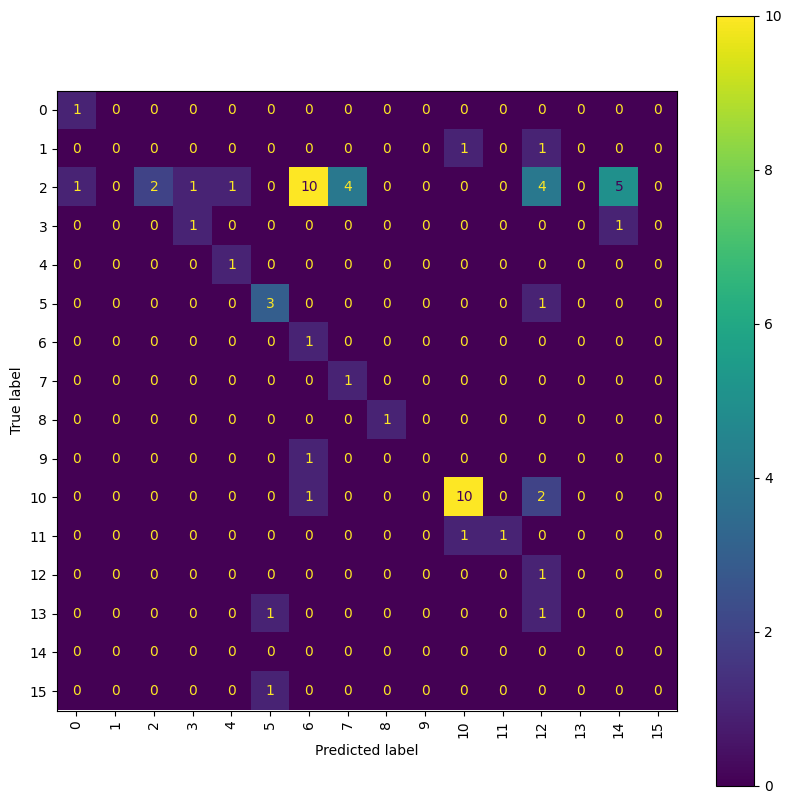

In [64]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred)#, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)#, display_labels=list(label_mapping.keys()))
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation="vertical")
plt.show()


In [65]:
df_recording

,name,NACE,label_description,nace_lvl_1,position_lvl_1,classes_lvl_1,classification_lvl_1,first_class_1
0,AAK AB1.txt_classifications.csv,10.89,Manufacture of other food products n.e.c.,C,1,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
1,ABB Ltd.2.txt_classifications.csv,27.11,"Manufacture of electric motors, generators and...",C,1,15,"{'M_PROFESSIONAL, SCIENTIFIC AND TECHNICAL ACT...",M
2,Accelleron Industries AG1.txt_classifications.csv,28.11,"Manufacture of engines and turbines, except ai...",C,3,15,{'H_TRANSPORTATION AND STORAGE': 1.18057705369...,H
3,Acciona SA2.txt_classifications.csv,41.2,Construction of residential and non-residentia...,F,0,15,"{'F_CONSTRUCTION': 0.9695349480649035, 'L_REAL...",F
4,Accor SA1.txt_classifications.csv,55.1,Hotels and similar accommodation,I,0,15,{'I_ACCOMMODATION AND FOOD SERVICE ACTIVITIES'...,I
...,...,...,...,...,...,...,...,...
56,Orkla ASA1.txt_classifications.csv,10.89,Manufacture of other food products n.e.c.,C,10,15,{'G_WHOLESALE AND RETAIL TRADE; REPAIR OF MOTO...,G
57,Scout24 SE3.txt_classifications.csv,96.09,Other personal service activities n.e.c.,S,16,15,"{'F_CONSTRUCTION': 1.1037059278693926, 'K_FINA...",F
58,Severn Trent Plc1.txt_classifications.csv,36.0,"Water collection, treatment and supply",E,0,15,"{'E_WATER SUPPLY; SEWERAGE, WASTE MANAGEMENT A...",E
59,Siemens Energy AG1.txt_classifications.csv,27.33,Manufacture of wiring devices,C,2,15,"{'D_ELECTRICITY, GAS, STEAM AND AIR CONDITIONI...",D


In [66]:
df_eval.max()

A                                                              0.463717
H                                                              6.347003
L                                                              1.151174
D                                                              0.152118
F                                                             -0.331561
I                                                              5.827204
G                                                              1.741954
C                                                              0.504519
M                                                             -1.287799
P                                                             -1.072613
Q                                                             -0.485745
J                                                             -0.337304
B                                                             -2.201748
K                                                             -0

In [67]:
df_softmax = df_eval[scores].apply(softmax, axis=1)
df_softmax.mean(0)

A    0.004073
H    0.128664
L    0.007674
D    0.001526
F    0.001480
I    0.839391
G    0.009149
C    0.000769
M    0.000623
P    0.000800
Q    0.001383
J    0.001766
B    0.000264
K    0.001125
E    0.001312
dtype: float64

In [68]:
df_softmax["max_class_sim"] = [scores[i] for i in np.argmax(df_softmax[scores], 1)]
df_softmax["max_sim"] = df_softmax[scores].max(1)
(df_softmax.groupby("max_class_sim")["max_sim"].sum().sort_values(ascending=False)/len(df_softmax)).to_dict()

{'I': 0.8373883170437373, 'H': 0.12020304159523205}